# Restaurant Data Analysis — Zomato Dataset

End-to-end analysis of Zomato restaurant listings: methodology, implementation, exploratory analysis, visualizations, and conclusions.


## Chapter 4 — Methodology and architecture

### 4.1 Development methodology

| Phase | Focus | Deliverable |
|------|--------|-------------|
| Phase 1 | Data collection | Zomato CSV imported |
| Phase 2 | Data cleaning and preprocessing | Missing values, duplicates, standardized types |
| Phase 3 | EDA | Relationships among ratings, cost, cuisines, location |
| Phase 4 | Data visualization | Bar charts, frequency plots, heatmaps, scatter |
| Phase 5 | ELT | SQLite storage and SQL queries |

### 4.2 Application architecture

Data source → Pandas/NumPy processing → EDA → Matplotlib/Seaborn visualization → SQLite ELT.

### 4.3 Notebook flow

1. Load the CSV  
2. Clean and type-cast key fields  
3. Print exploratory summaries (cities, cuisines, service flags)  
4. Scatter plot (ratings vs votes), correlation heatmap, SQLite export and sample queries  
5. Feature engineering (derived columns)  
6. Main visualization suite (figures 1–3 and 5); figure 4 is the same scatter as step 4, so it is saved once  
7. Feature verification checklist  


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project palette (primary blue + light accent)
BLUE = '#1f77b4'
SKY = '#AED6F1'

plt.rcParams.update({
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
})
sns.set_theme(style='whitegrid')


def project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'zomato.csv').exists():
            return p
    raise FileNotFoundError('zomato.csv not found — run from the Data Science Project folder.')


PROJECT_DIR = project_root()
CSV_PATH = PROJECT_DIR / 'zomato.csv'
OUT_DIR = PROJECT_DIR / 'outputs'
DB_PATH = PROJECT_DIR / 'zomato.db'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('PROJECT_DIR:', PROJECT_DIR)


PROJECT_DIR: /Users/riteshgarg/Downloads/Data Science Project


## Chapter 5 — Implementation

### Module 1 — Data collection


In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Raw shape:', df.shape)
print(df.iloc[:2, [1, 2, 5, 9, 12]].to_string())


Raw shape: (51717, 17)
                                                                                                address            name   rate      rest_type approx_cost(for two people)
0                                               942, 21st Main Road, 2nd Stage, Banashankari, Bangalore           Jalsa  4.1/5  Casual Dining                         800
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th Block, Kathriguppe, 3rd Stage, Banashankari, Bangalore  Spice Elephant  4.1/5  Casual Dining                         800


### Module 2 — Data cleaning and preprocessing


In [3]:
df = df.copy()
df.drop_duplicates(inplace=True)
df.dropna(subset=['rate', 'approx_cost(for two people)'], inplace=True)

df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

df.dropna(subset=['rate'], inplace=True)
print(df.head())
print('Shape after cleaning:', df.shape)


                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table  rate  votes                             phone  \
0          Yes        Yes   4.1    775    080 42297555\r\n+91 9743772233   
1          Yes         No   4.1    7

### Module 3 — Exploratory Data Analysis


In [4]:
city_counts = df['listed_in(city)'].value_counts().head(15)
print('--- Top cities (listed_in(city)) ---')
print(city_counts)

cuisine_series = (
    df['cuisines'].dropna().astype(str).str.split(',').explode().str.strip()
)
cuisine_counts = cuisine_series[cuisine_series.ne('')].value_counts().head(15)
print('\n--- Top 15 cuisine tags ---')
print(cuisine_counts)

print('\n--- Mean rating: online_order ---')
print(df.groupby('online_order')['rate'].mean())
print('\n--- Mean rating: book_table ---')
print(df.groupby('book_table')['rate'].mean())


--- Top cities (listed_in(city)) ---
listed_in(city)
BTM                      2599
Koramangala 7th Block    2371
Koramangala 4th Block    2262
Koramangala 5th Block    2260
Koramangala 6th Block    2128
Jayanagar                1923
JP Nagar                 1645
Indiranagar              1544
Church Street            1518
MG Road                  1515
Brigade Road             1483
Lavelle Road             1451
Residency Road           1345
HSR                      1335
Marathahalli             1305
Name: count, dtype: int64

--- Top 15 cuisine tags ---
cuisines
North Indian    17310
Chinese         12930
South Indian     6369
Fast Food        6340
Continental      5202
Biryani          5060
Cafe             4785
Desserts         4512
Beverages        3839
Italian          3188
Street Food      2219
Bakery           2023
Pizza            1877
Burger           1845
Seafood          1649
Name: count, dtype: int64

--- Mean rating: online_order ---
online_order
No     3.658071
Yes    3.7224

### Scatter plot — ratings vs votes


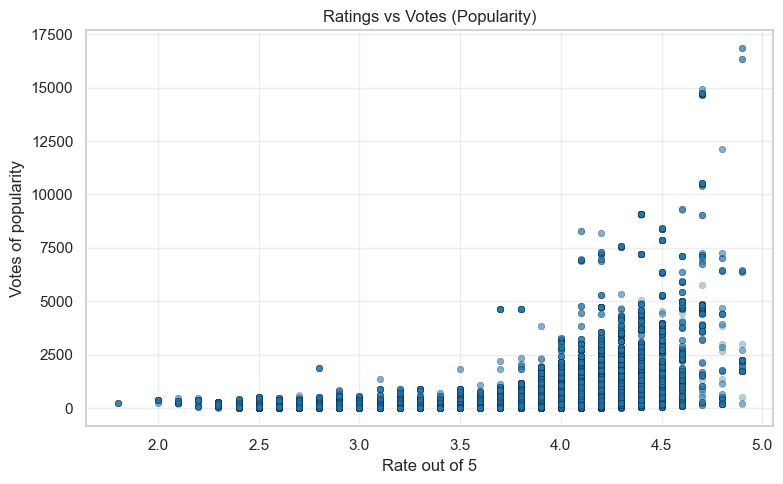

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df['rate'], df['votes'], c=BLUE, edgecolors='black', linewidths=0.25, alpha=0.35, s=22)
plt.title('Ratings vs Votes (Popularity)')
plt.xlabel('Rate out of 5')
plt.ylabel('Votes of popularity')
plt.tight_layout()
plt.savefig(OUT_DIR / '04_rating_vs_votes_scatter.png', dpi=150)
plt.show()


### Correlation heatmap


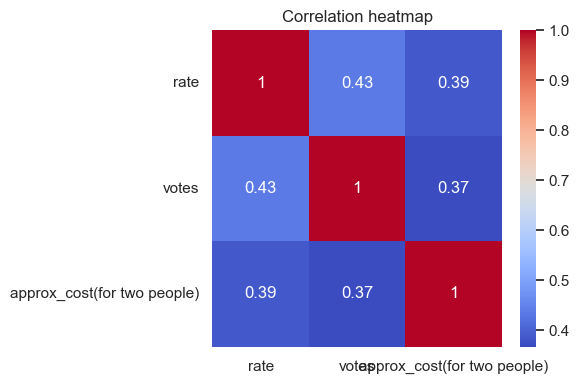

                                 rate     votes  approx_cost(for two people)
rate                         1.000000  0.434764                     0.385183
votes                        0.434764  1.000000                     0.366700
approx_cost(for two people)  0.385183  0.366700                     1.000000


In [6]:
corr = df[['rate', 'votes', 'approx_cost(for two people)']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig(OUT_DIR / '06_correlation_heatmap.png', dpi=150)
plt.show()
print(corr)


### SQLite — load cleaned data, then add features in memory

Persist the cleaned frame **before** feature engineering so the database mirrors the cleaned core columns.


In [7]:
if DB_PATH.exists():
    DB_PATH.unlink()
conn = sqlite3.connect(DB_PATH)
df.to_sql('zomato', conn, index=False, if_exists='replace')

query_top = """
SELECT location, name, rate
FROM zomato
WHERE rate IS NOT NULL
ORDER BY rate DESC
LIMIT 10;
"""
top_restaurants = pd.read_sql(query_top, conn)
print('--- Top 10 restaurants by rating ---')
print(top_restaurants.to_string(index=False))

cuisine_df = pd.read_sql('SELECT cuisines FROM zomato WHERE cuisines IS NOT NULL', conn)
tags = cuisine_df['cuisines'].astype(str).str.split(',').explode().str.strip()
tags = tags[tags.ne('') & tags.ne('nan')]
print('\n--- Top 10 cuisine tags (SQLite) ---')
print(tags.value_counts().head(10))

conn.close()
print('\nDatabase path:', DB_PATH)


--- Top 10 restaurants by rating ---
             location                           name  rate
        Sarjapur Road    Byg Brewski Brewing Company   4.9
        Sarjapur Road    Byg Brewski Brewing Company   4.9
        Sarjapur Road    Byg Brewski Brewing Company   4.9
         Brigade Road         Belgian Waffle Factory   4.9
         Brigade Road         Belgian Waffle Factory   4.9
           Whitefield                       Flechazo   4.9
           Whitefield                   Punjab Grill   4.9
           Whitefield                       Flechazo   4.9
                  BTM      AB's - Absolute Barbecues   4.9
Koramangala 5th Block Asia Kitchen By Mainland China   4.9

--- Top 10 cuisine tags (SQLite) ---
cuisines
North Indian    17310
Chinese         12930
South Indian     6369
Fast Food        6340
Continental      5202
Biryani          5060
Cafe             4785
Desserts         4512
Beverages        3839
Italian          3188
Name: count, dtype: int64

Database path: /User

### Feature engineering


In [8]:
df['cost_per_person'] = df['approx_cost(for two people)'] / 2


def rating_category(rating):
    if rating >= 4:
        return 'Excellent'
    elif rating >= 3:
        return 'Good'
    else:
        return 'Average'


df['rating_category'] = df['rate'].apply(rating_category)
print(df[['rate', 'rating_category']].head())
print(df['rating_category'].value_counts())


   rate rating_category
0   4.1       Excellent
1   4.1       Excellent
2   3.8            Good
3   3.7            Good
4   3.8            Good
rating_category
Good         26862
Excellent    12307
Average       2249
Name: count, dtype: int64


## Chapter 6 — EDA and output

### Visualizations

Palette: primary blue (`#1f77b4`) and accent sky blue (`#AED6F1`), light grid, black bar edges where used. **Figure 4** (rating vs votes scatter) is the same chart as in Chapter 5 — already saved as `04_rating_vs_votes_scatter.png`.


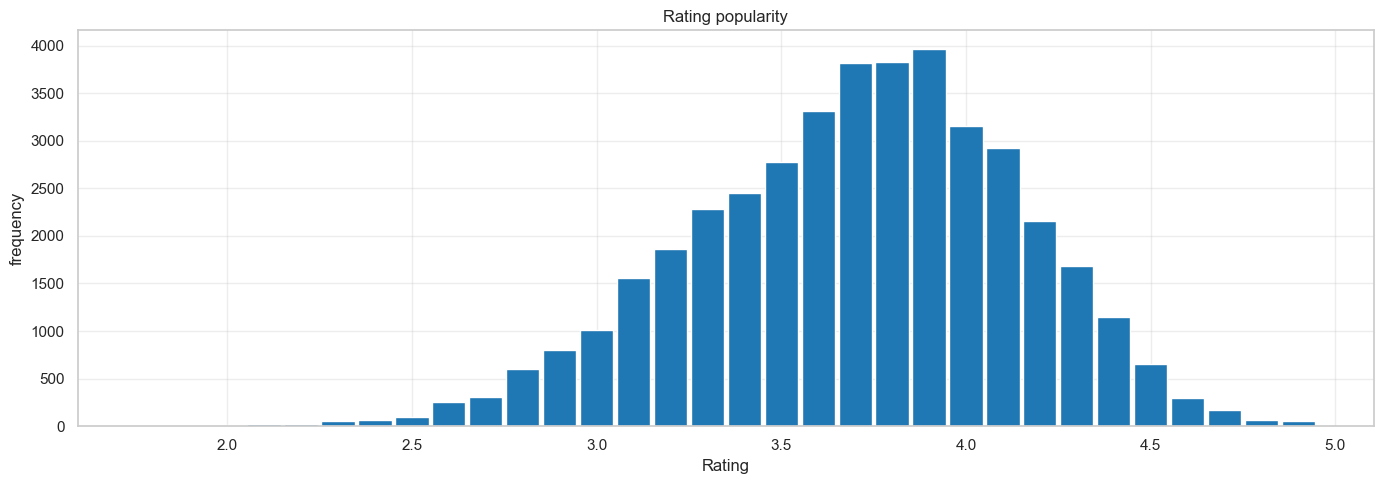

In [9]:
# (1) Rating popularity — frequency by rounded rating
freq = df['rate'].round(1).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 5))
x = freq.index.astype(float)
ax.bar(x, freq.values, width=0.09, color=BLUE, align='center')
ax.set_title('Rating popularity')
ax.set_xlabel('Rating')
ax.set_ylabel('frequency')
plt.tight_layout()
plt.savefig(OUT_DIR / '01_rating_popularity.png', dpi=150)
plt.show()


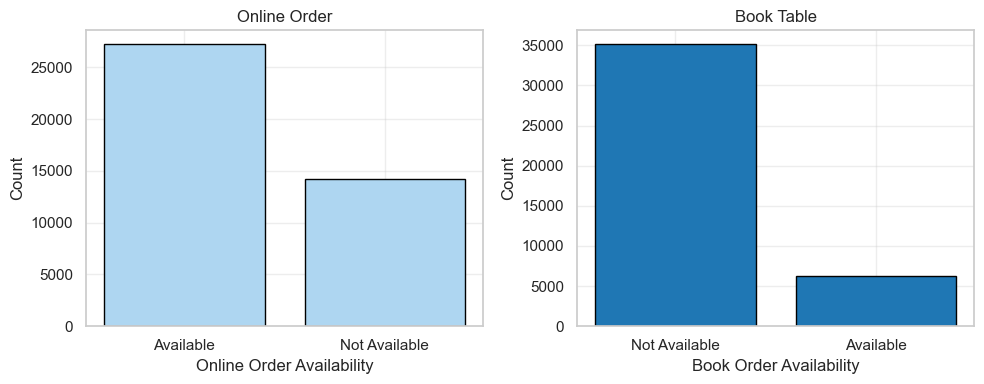

In [10]:
# (2) Online order and book table — restaurant counts (not mean rating)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
order_lab = df['online_order'].map({'Yes': 'Available', 'No': 'Not Available'})
oc = order_lab.value_counts().reindex(['Available', 'Not Available'])
axes[0].bar(oc.index.astype(str), oc.values, color=SKY, edgecolor='black')
axes[0].set_title('Online Order')
axes[0].set_xlabel('Online Order Availability')
axes[0].set_ylabel('Count')

book_lab = df['book_table'].map({'Yes': 'Available', 'No': 'Not Available'})
bc = book_lab.value_counts().reindex(['Not Available', 'Available'])
axes[1].bar(bc.index.astype(str), bc.values, color=BLUE, edgecolor='black')
axes[1].set_title('Book Table')
axes[1].set_xlabel('Book Order Availability')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUT_DIR / '02_online_order_booking_comparison.png', dpi=150)
plt.show()


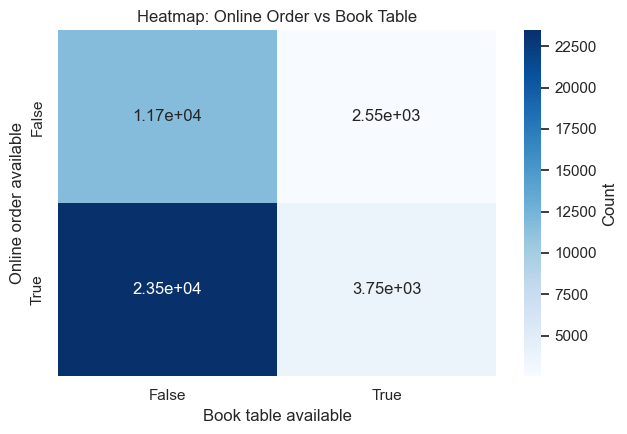

In [11]:
# (3) Count heatmap: online order vs book table
oo = df['online_order'] == 'Yes'
bt = df['book_table'] == 'Yes'
ct = pd.crosstab(oo, bt)
ct.index = ['False', 'True']
ct.columns = ['False', 'True']
plt.figure(figsize=(6.5, 4.5))
sns.heatmap(ct, annot=True, fmt='.2e', cmap='Blues', cbar_kws={'label': 'Count'})
plt.ylabel('Online order available')
plt.xlabel('Book table available')
plt.title('Heatmap: Online Order vs Book Table')
plt.tight_layout()
plt.savefig(OUT_DIR / '03_online_order_booking_heatmap.png', dpi=150)
plt.show()


**(4) Rating vs votes** — same plot as in Chapter 5 (`04_rating_vs_votes_scatter.png`).


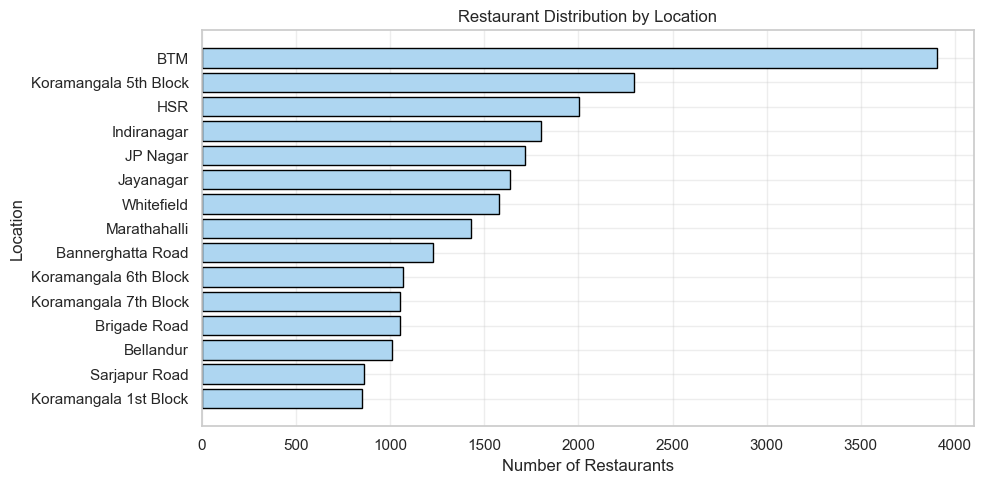

In [12]:
# (5) Restaurant distribution by location
loc_counts = df['location'].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(loc_counts.index.astype(str), loc_counts.values, color=SKY, edgecolor='black')
ax.set_title('Restaurant Distribution by Location')
ax.set_xlabel('Number of Restaurants')
ax.set_ylabel('Location')
plt.tight_layout()
plt.savefig(OUT_DIR / '05_restaurants_by_location.png', dpi=150)
plt.show()


### Feature verification


In [13]:
verification = pd.DataFrame(
    [
        ['Data Loading (CSV Import)', 'Working', 'Zomato dataset loaded using Pandas'],
        ['Data Cleaning', 'Working', 'Missing values, duplicates, inconsistent formats handled'],
        ['Data Transformation', 'Working', 'Ratings and cost converted to numerical formats'],
        ['Exploratory Data Analysis (EDA)', 'Working', 'Patterns across ratings, votes, cuisines, locations'],
        ['Data Visualization', 'Working', 'Charts generated using Matplotlib and Seaborn'],
        ['Correlation Analysis', 'Working', 'Heatmap for rate, votes, approx_cost'],
        ['Feature Engineering', 'Working', 'cost_per_person and rating_category'],
        ['SQLite Integration (ELT)', 'Working', 'Cleaned data stored in zomato.db'],
        ['SQL Query Execution', 'Working', 'Top-rated restaurants and popular cuisines'],
        ['Insight Generation', 'Working', 'Meaningful trends identified from the dataset'],
    ],
    columns=['Feature', 'Status', 'Notes'],
)
print(verification.to_string(index=False))


                        Feature  Status                                                    Notes
      Data Loading (CSV Import) Working                       Zomato dataset loaded using Pandas
                  Data Cleaning Working Missing values, duplicates, inconsistent formats handled
            Data Transformation Working          Ratings and cost converted to numerical formats
Exploratory Data Analysis (EDA) Working      Patterns across ratings, votes, cuisines, locations
             Data Visualization Working            Charts generated using Matplotlib and Seaborn
           Correlation Analysis Working                     Heatmap for rate, votes, approx_cost
            Feature Engineering Working                      cost_per_person and rating_category
       SQLite Integration (ELT) Working                         Cleaned data stored in zomato.db
            SQL Query Execution Working               Top-rated restaurants and popular cuisines
             Insight Generatio

## Conclusion

This project loads the Zomato Bangalore listings CSV, cleans and types key fields, explores city and cuisine patterns, visualizes ratings and service options, quantifies linear relationships with a correlation heatmap, and stores the cleaned table in SQLite for reusable queries. Derived features (`cost_per_person`, `rating_category`) support segmentation for further analysis.

### Takeaways

- Built a repeatable Pandas workflow for messy restaurant data.
- Combined Matplotlib and Seaborn for distribution, count, heatmap, and scatter views.
- Used SQLite as a lightweight warehouse for ranking and cuisine-frequency queries.
- Practiced feature engineering and checklist-style verification before drawing conclusions.
